**Эксперимент П.21** — винтовая траектория, сравнение ANSYS и опыта (как в `P29/experimental_vint`).

В данной работе проводится сравнение результатов расчета напряженно-деформированного состояния (НДС) тонкостенного трубчатого образца при сложном нагружении по винтовой траектории.

**Материал:** Сталь 45 (модель **CHAB** — несколько компонент кинематического упрочнения).

**Цель:** Анализ векторных и скалярных свойств материала, проверка корректности моделирования в ANSYS.

In [1]:
from core.reader import load_experimental_data
from core.calculations import calculate_von_mises_stress

real_experiment_data_folder = "."
real_experiment = load_experimental_data(real_experiment_data_folder)
real_experiment = calculate_von_mises_stress(
            real_experiment,
            s_x_col="S_TT",
            s_y_col="S_ZZ",
            s_xy_col="S_TZ",
            new_col_name="S_EQV"
        )

### Методика проведения численного эксперимента

Расчет в **ANSYS** выполнялся в деформационном нагружении **поточечно**. Процесс моделирования был организован следующим образом:

*   **Синхронизация по шагам:** На каждом расчетном шаге (step) производилось прямое сопоставление с временной шкалой реального эксперимента.
*   **Граничные условия:** В качестве входных параметров численной модели на каждом шаге использовались компоненты тензора деформаций, полученные непосредственно из экспериментальных данных.
*   **Итерационный расчет:** Программа вычисляла отклик системы (напряжения) для каждой конкретной точки деформационного пути, что позволило обеспечить максимально точное соответствие условий нагружения в модели и в реальности.

*   **Два варианта материала в ANSYS:** сжимаемый и **несжимаемый** (`chab.csv` и `chab_incompressible.csv`); на графиках — две расчётные кривые и эксперимент.


In [2]:
from core.reader import read_ansys_csv

numerical_experiment_chab = read_ansys_csv("chab.csv")
numerical_experiment_chab_inc = read_ansys_csv("chab_incompressible.csv")



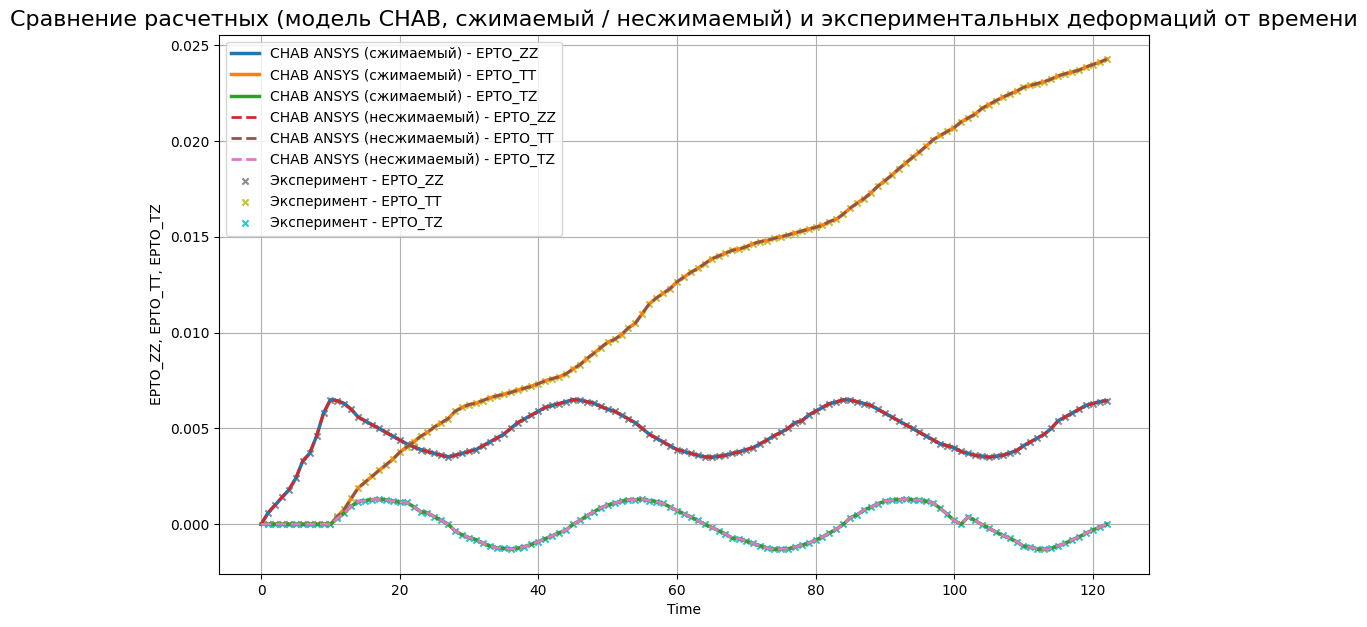

In [3]:
from core.visualizer import plot_xy

model_name = "CHAB"
_ansys_pairs = [
    (f"{model_name} ANSYS (сжимаемый)", numerical_experiment_chab),
    (f"{model_name} ANSYS (несжимаемый)", numerical_experiment_chab_inc),
]
plot_xy(
    _ansys_pairs,
    "Time",
    ["EPTO_ZZ", "EPTO_TT", "EPTO_TZ"],
    f"Сравнение расчетных (модель {model_name}, сжимаемый / несжимаемый) и экспериментальных деформаций от времени",
    ("Эксперимент", real_experiment),
    figsize=(12, 7),
)



Построим графики изменения компонент тензора напряжений и интенсивности напряжений от времени.

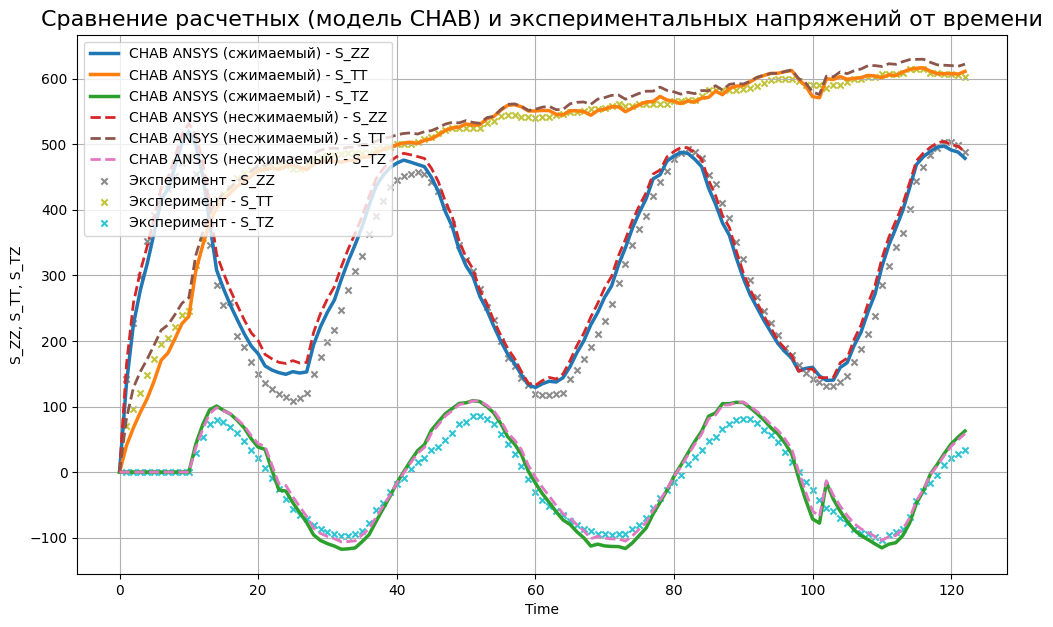

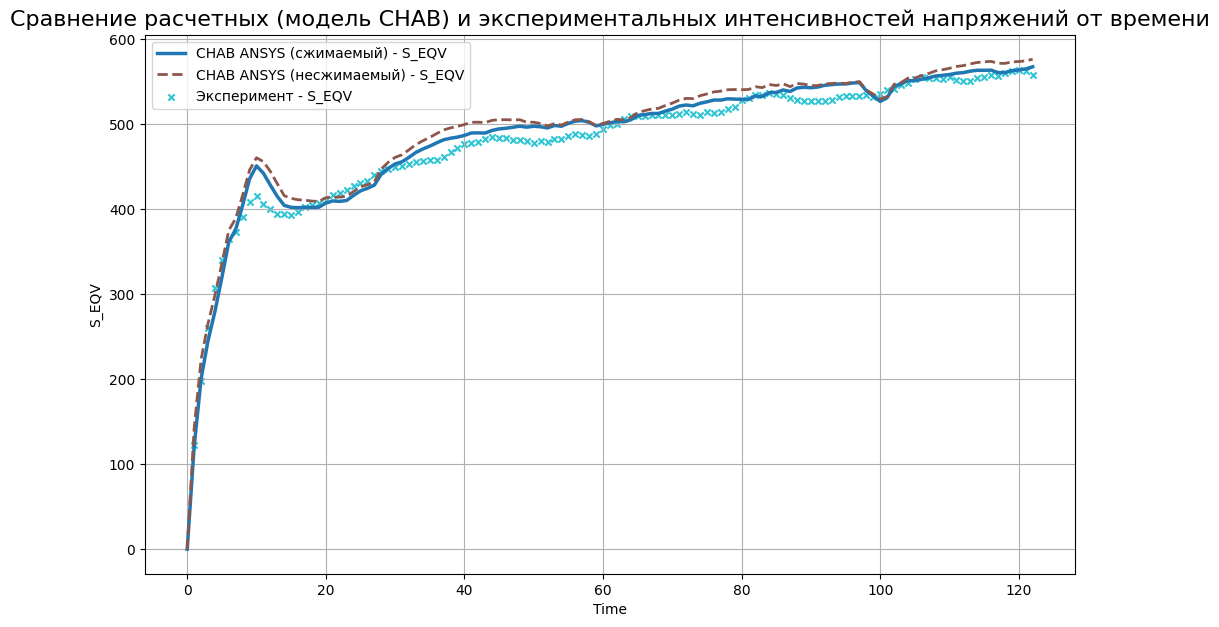

In [4]:
plot_xy(
    _ansys_pairs,
    "Time",
    ["S_ZZ", "S_TT", "S_TZ"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных напряжений от времени",
    ("Эксперимент", real_experiment),
    figsize=(12, 7),
)

plot_xy(
    _ansys_pairs,
    "Time",
    ["S_EQV"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных интенсивностей напряжений от времени",
    ("Эксперимент", real_experiment),
    figsize=(12, 7),
)



### Сравнительный анализ в пространстве Ильюшина и длина пути

В пространстве деформаций Ильюшина каждой точке процесса соответствует вектор $(\varepsilon_1^{Il}, \varepsilon_2^{Il}, \varepsilon_3^{Il})$, в пространстве напряжений Ильюшина — вектор $(\sigma_1^{Il}, \sigma_2^{Il}, \sigma_3^{Il})$.

**Длина дуги $s$.** Точки нагружения упорядочены по времени. Между двумя соседними точками задаём приращение
$\Delta\varepsilon_i^{Il} = \varepsilon_i^{Il}(t_{k+1}) - \varepsilon_i^{Il}(t_k)$, $i=1,2,3$.
Евклидова длина шага в пространстве деформаций Ильюшина:
$$\Delta s_k = \sqrt{(\Delta\varepsilon_1^{Il})^2 + (\Delta\varepsilon_2^{Il})^2 + (\Delta\varepsilon_3^{Il})^2}.$$
Накопленная длина пути от начала процесса: $s_0 = 0$, $s_k = \sum_{j=0}^{k-1} \Delta s_j$.

**Какие графики строятся.**
Для ANSYS используются **два** расчёта: **сжимаемый** и **несжимаемый** (`chab.csv`, `chab_incompressible.csv`); на графиках — **две линии** расчёта и эксперимент точками.
 Компоненты $\varepsilon_i^{Il}$ и $\sigma_i^{Il}$, угол $\varphi$ и относительная разность модулей на графиках ниже — **по времени** $t$ (столбец `Time`).

#### Угол между векторами напряжений Ильюшина ($\varphi$)
$$\varphi = \arccos\left(\frac{\vec{\sigma}^{\mathrm{числ}} \cdot \vec{\sigma}^{\mathrm{эксп}}}{|\vec{\sigma}^{\mathrm{числ}}| \cdot |\vec{\sigma}^{\mathrm{эксп}}|}\right).$$

#### Относительная разность модулей
$$\frac{|\vec{\sigma}^{\mathrm{числ}}| - |\vec{\sigma}^{\mathrm{эксп}}|}{|\vec{\sigma}^{\mathrm{эксп}}|}.$$


In [12]:
from core.calculations import prepare_ilushin_path_dataset

exp_il = prepare_ilushin_path_dataset(real_experiment, use_deviatoric_strains=False)
num_il = prepare_ilushin_path_dataset(numerical_experiment_chab, use_deviatoric_strains=True)
num_il_inc = prepare_ilushin_path_dataset(numerical_experiment_chab_inc, use_deviatoric_strains=True)

_il_pairs = [
    (f"{model_name} (сжимаемый)", num_il),
    (f"{model_name} (несжимаемый)", num_il_inc),
]



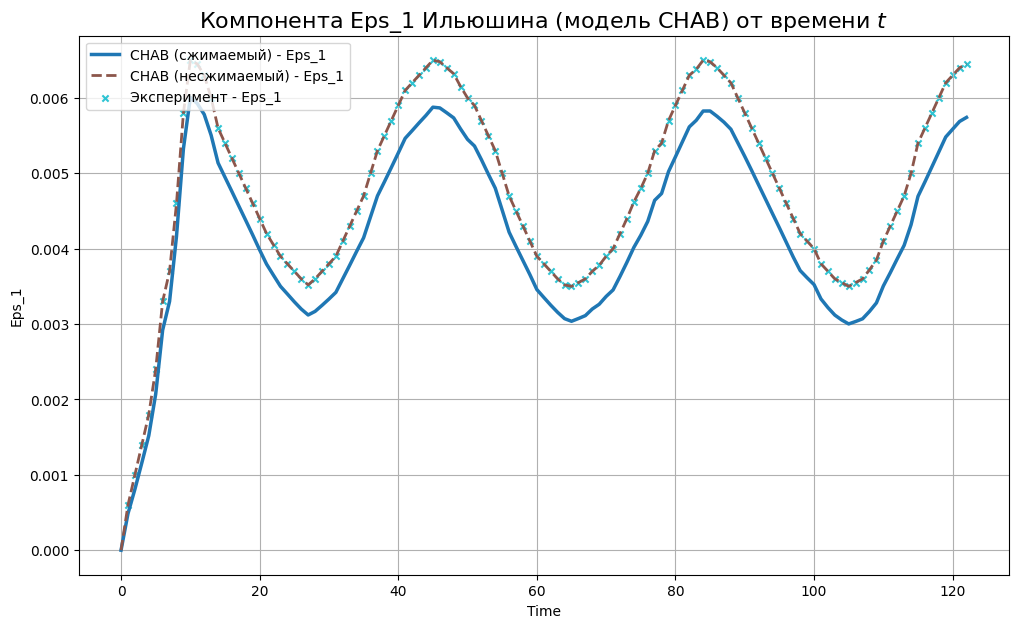

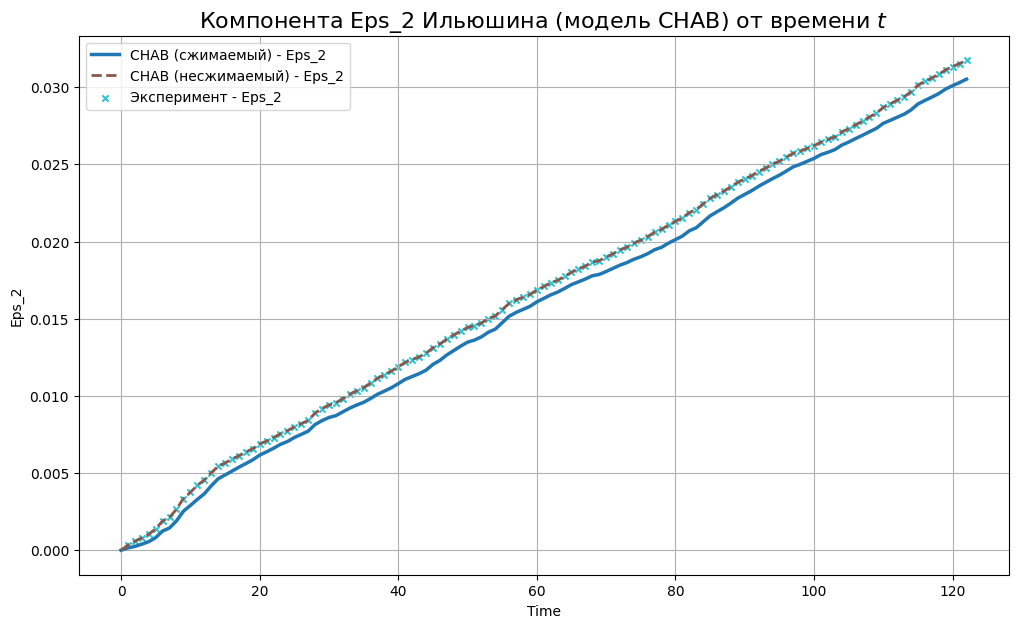

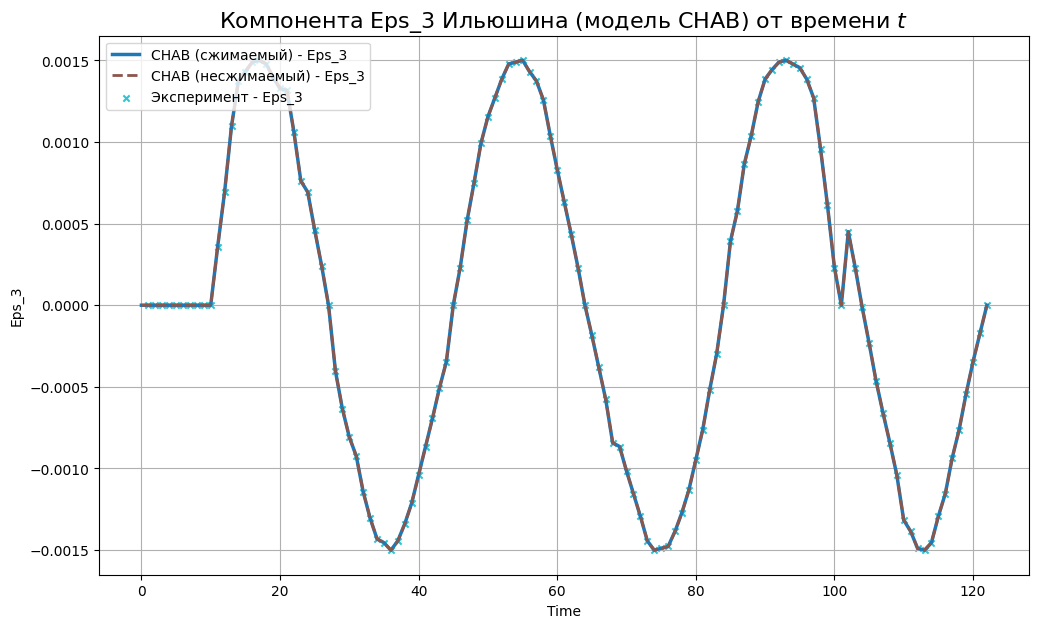

In [13]:
plot_xy(
    _il_pairs,
    "Time",
    ["Eps_1"],
    f"Компонента Eps_1 Ильюшина (модель {model_name}) от времени $t$",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)

plot_xy(
    _il_pairs,
    "Time",
    ["Eps_2"],
    f"Компонента Eps_2 Ильюшина (модель {model_name}) от времени $t$",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)

plot_xy(
    _il_pairs,
    "Time",
    ["Eps_3"],
    f"Компонента Eps_3 Ильюшина (модель {model_name}) от времени $t$",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)



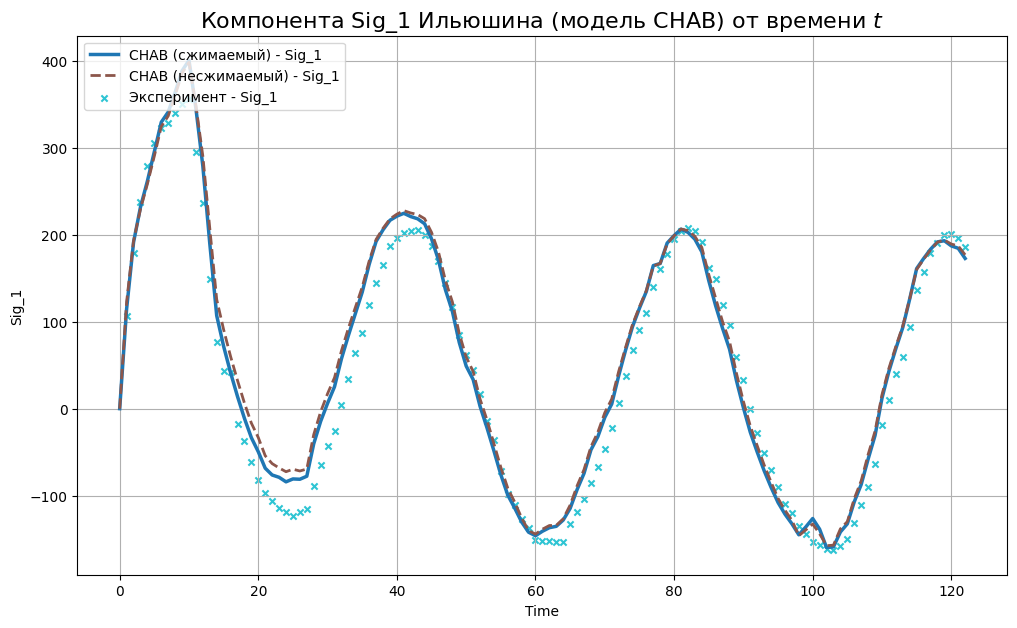

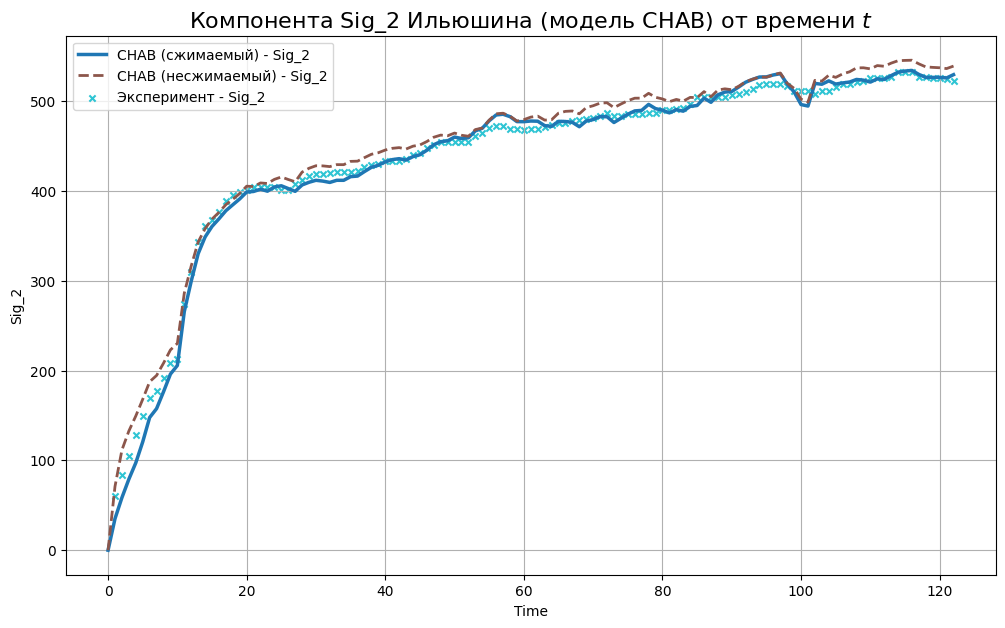

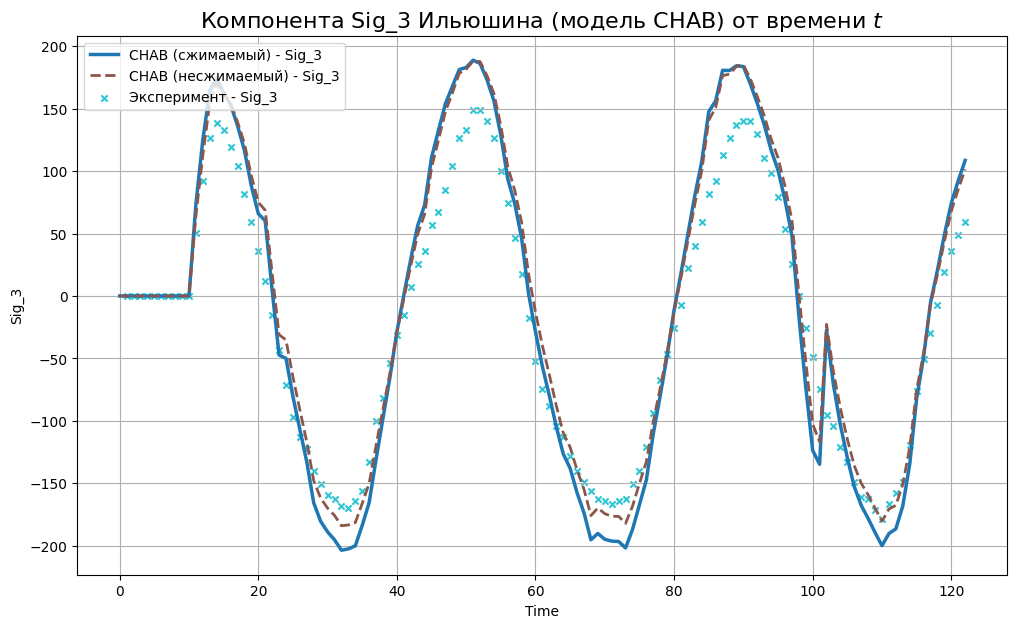

In [14]:
plot_xy(
    _il_pairs,
    "Time",
    ["Sig_1"],
    f"Компонента Sig_1 Ильюшина (модель {model_name}) от времени $t$",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)

plot_xy(
    _il_pairs,
    "Time",
    ["Sig_2"],
    f"Компонента Sig_2 Ильюшина (модель {model_name}) от времени $t$",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)

plot_xy(
    _il_pairs,
    "Time",
    ["Sig_3"],
    f"Компонента Sig_3 Ильюшина (модель {model_name}) от времени $t$",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)



In [17]:
from core.calculations import ilushin_stress_metrics_at_experiment

df_metrics = ilushin_stress_metrics_at_experiment(
    real_experiment,
    numerical_experiment_chab,
    time_col="Time",
    direction="nearest",
)
df_metrics_inc = ilushin_stress_metrics_at_experiment(
    real_experiment,
    numerical_experiment_chab_inc,
    time_col="Time",
    direction="nearest",
)

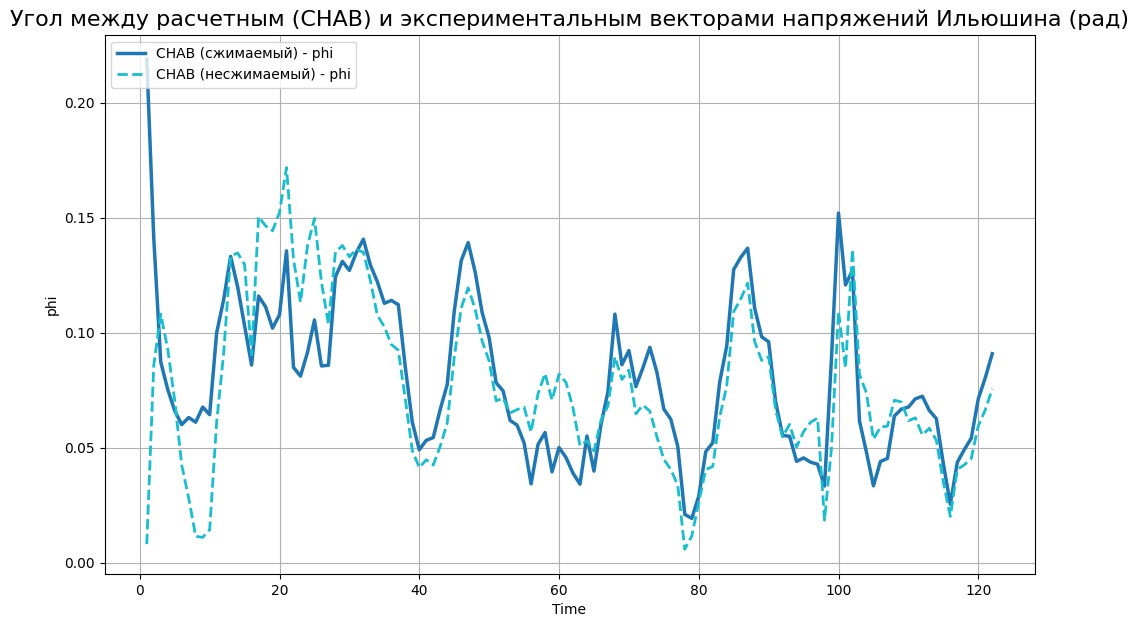

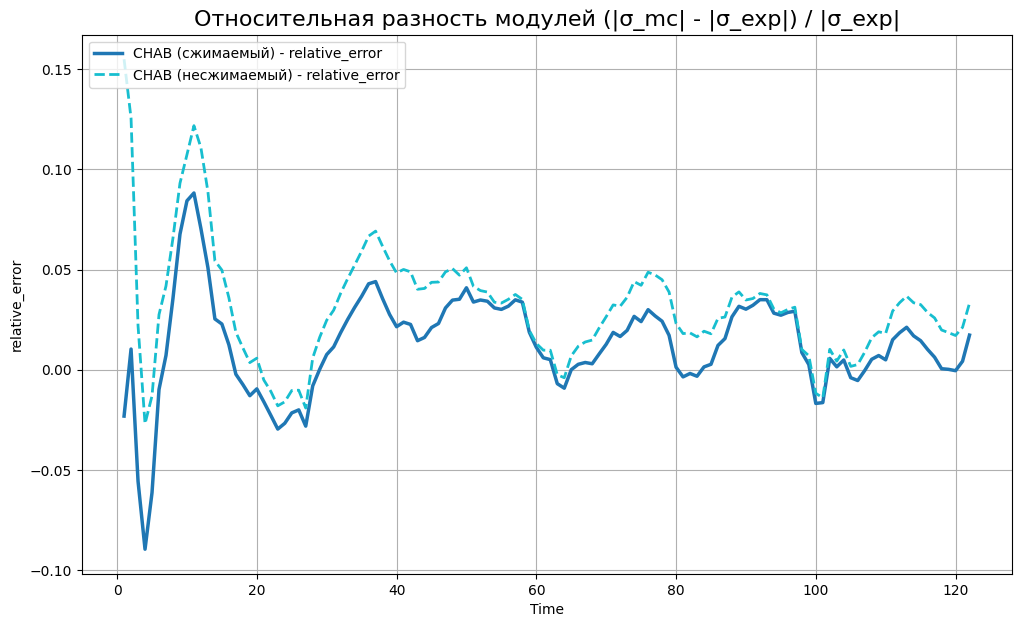

In [18]:
plot_xy(
    data_pairs=[
        (f"{model_name} (сжимаемый)", df_metrics),
        (f"{model_name} (несжимаемый)", df_metrics_inc),
    ],
    x_col="Time",
    y_cols=["phi"],
    title=f"Угол между расчетным ({model_name}) и экспериментальным векторами напряжений Ильюшина (рад)",
    figsize=(12, 7),
)

plot_xy(
    data_pairs=[
        (f"{model_name} (сжимаемый)", df_metrics),
        (f"{model_name} (несжимаемый)", df_metrics_inc),
    ],
    x_col="Time",
    y_cols=["relative_error"],
    title=f"Относительная разность модулей (|σ_mc| - |σ_exp|) / |σ_exp|",
    figsize=(12, 7),
)

